In [1]:
# 1. SETUP

import json
import math
import platform
import shutil
import subprocess
import sys
import warnings
from dataclasses import dataclass
from pathlib import Path

try:
    import gymnasium as gym
    from gymnasium import spaces
    from gymnasium.utils.env_checker import check_env
except ImportError:
    subprocess.check_call(
        [
            sys.executable,
            '-m',
            'pip',
            'install',
            '-q',
            'gymnasium',
        ]
    )
    import gymnasium as gym
    from gymnasium import spaces
    from gymnasium.utils.env_checker import check_env

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_SEED = 42
N_RANDOM_MISSIONS = 200
BOOTSTRAP_ITERATIONS = 1_000

BASE_ACTION_DURATION_MIN = 1.0
WARNING_POWER_MULTIPLIER = 0.65
SAFE_MODE_POWER_MULTIPLIER = 0.35
HOUSEKEEPING_POWER_W = 30.0

MIN_TEMPERATURE_CAPACITY_FACTOR = 0.75
MIN_PACK_EFFICIENCY = 0.78
MAX_PACK_EFFICIENCY = 0.96

BASE_OUTPUT_DIR = Path(
    '/content/final_gymnasium_controller_benchmark_outputs'
)
FIXED_OUTPUT_DIR = BASE_OUTPUT_DIR / 'fixed_scenarios'
RANDOM_OUTPUT_DIR = BASE_OUTPUT_DIR / 'randomised_benchmark'
PLOT_OUTPUT_DIR = BASE_OUTPUT_DIR / 'plots'
AUDIT_OUTPUT_DIR = BASE_OUTPUT_DIR / 'telemetry_audit'
FAILURE_OUTPUT_DIR = BASE_OUTPUT_DIR / 'failure_cases'
ROUTE_OUTPUT_DIR = BASE_OUTPUT_DIR / 'route_visualisations'

for folder in [
    BASE_OUTPUT_DIR,
    FIXED_OUTPUT_DIR,
    RANDOM_OUTPUT_DIR,
    PLOT_OUTPUT_DIR,
    AUDIT_OUTPUT_DIR,
    FAILURE_OUTPUT_DIR,
    ROUTE_OUTPUT_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

EXPLICIT_MODEL_DIRS = [
    Path(
        '/content/drive/MyDrive/dissertation/'
        '02_nasa_physical_targets_final_outputs/model_bundle'
    ),
    Path(
        '/content/final_nasa_physical_targets_outputs/model_bundle'
    ),
]
DRIVE_OUTPUT_DIR = Path(
    '/content/drive/MyDrive/dissertation/'
    '03_gymnasium_controller_benchmark_outputs'
)

try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
except Exception as exc:
    print('Google Drive mount skipped or unavailable:', exc)

np.random.seed(RANDOM_SEED)

print('Output folder:', BASE_OUTPUT_DIR)
print('Python:', platform.python_version())
print('Gymnasium:', getattr(gym, '__version__', 'unknown'))
print('scikit-learn:', __import__('sklearn').__version__)

Mounted at /content/drive
Output folder: /content/final_gymnasium_controller_benchmark_outputs
Python: 3.12.13
Gymnasium: 1.3.0
scikit-learn: 1.6.1


In [2]:
# 2. LOCATE, LOAD, AND PREFLIGHT CHECK THE NASA MODEL BUNDLE

REQUIRED_MODEL_FILES = {
    'soc_drop_model': 'practical_soc_drop_regressor.joblib',
    'risk_model': 'practical_future_risk_classifier.joblib',
    'soc_drop_features': 'practical_soc_drop_features.joblib',
    'risk_features': 'practical_future_risk_features.joblib',
    'metadata': 'model_bundle_metadata.json',
    'feature_ranges': 'practical_feature_ranges.csv',
    'reference_sample': 'practical_feature_reference_sample.csv',
}


def is_complete_bundle(folder):
    folder = Path(folder)
    return (
        folder.exists()
        and folder.is_dir()
        and all(
            (folder / filename).exists()
            for filename in REQUIRED_MODEL_FILES.values()
        )
    )


def locate_model_directory():
    for candidate in EXPLICIT_MODEL_DIRS:
        if is_complete_bundle(candidate):
            return candidate

    search_root = Path('/content/drive/MyDrive/dissertation')
    if search_root.exists():
        for metadata_path in search_root.rglob(
            REQUIRED_MODEL_FILES['metadata']
        ):
            candidate = metadata_path.parent
            if is_complete_bundle(candidate):
                return candidate

    searched = '\n'.join(
        f'- {candidate}'
        for candidate in EXPLICIT_MODEL_DIRS
    )
    raise FileNotFoundError(
        'A complete practical NASA model bundle was not found.\n'
        'Run the final NASA notebook completely first.\n'
        f'Searched explicit locations:\n{searched}'
    )


MODEL_DIR = locate_model_directory()

soc_drop_model = joblib.load(
    MODEL_DIR / REQUIRED_MODEL_FILES['soc_drop_model']
)
future_risk_model = joblib.load(
    MODEL_DIR / REQUIRED_MODEL_FILES['risk_model']
)
soc_drop_features = list(
    joblib.load(
        MODEL_DIR / REQUIRED_MODEL_FILES['soc_drop_features']
    )
)
future_risk_features = list(
    joblib.load(
        MODEL_DIR / REQUIRED_MODEL_FILES['risk_features']
    )
)

with open(
    MODEL_DIR / REQUIRED_MODEL_FILES['metadata'],
    encoding='utf-8',
) as file:
    model_metadata = json.load(file)

feature_ranges_df = pd.read_csv(
    MODEL_DIR / REQUIRED_MODEL_FILES['feature_ranges']
)
nasa_reference_df = pd.read_csv(
    MODEL_DIR / REQUIRED_MODEL_FILES['reference_sample']
)

feature_ranges = (
    feature_ranges_df
    .set_index('feature')
    .to_dict(orient='index')
)

HORIZON_SECONDS = float(
    model_metadata['forecast_horizon_seconds']
)
ROLLING_WINDOW_SECONDS = float(
    model_metadata['rolling_feature_window_seconds']
)
CRITICAL_SOC_THRESHOLD = float(
    model_metadata['risk_thresholds_percent']['critical_below']
)
SAFE_SOC_THRESHOLD = float(
    model_metadata['risk_thresholds_percent']['safe_at_or_above']
)

if not np.isclose(HORIZON_SECONDS, 120.0):
    raise RuntimeError(
        'The benchmark requires the exact 120-second NASA bundle. '
        f'Loaded horizon: {HORIZON_SECONDS}'
    )

SUPPORTED_FEATURES = {
    'voltage_measured_v',
    'current_measured_a',
    'temperature_measured_c',
    'current_load_a',
    'voltage_load_v',
    'current_abs_rolling_mean_60s',
    'voltage_slope_v_per_min_60s',
    'temperature_rolling_mean_60s',
    'soc_slope_percent_per_min_60s',
    'power_proxy_w',
    'operational_soc_percent',
    'prior_capacity_estimate_ah',
    'soh_percent_causal',
    'capacity_fade_percent_causal',
    'time_s',
    'cycle_index',
}

all_required_features = list(
    dict.fromkeys(
        soc_drop_features + future_risk_features
    )
)
unsupported = [
    feature
    for feature in all_required_features
    if feature not in SUPPORTED_FEATURES
]
if unsupported:
    raise RuntimeError(
        'The saved practical models use unsupported features: '
        f'{unsupported}'
    )

missing_reference = [
    feature
    for feature in all_required_features
    if feature not in nasa_reference_df.columns
]
if missing_reference:
    raise RuntimeError(
        'The NASA reference sample is missing model features: '
        f'{missing_reference}'
    )

if hasattr(future_risk_model, 'classes_'):
    classifier_classes = {
        str(value).strip().lower()
        for value in future_risk_model.classes_
    }
    expected_classes = {'safe', 'warning', 'critical'}
    if classifier_classes != expected_classes:
        raise RuntimeError(
            'Unexpected classifier classes: '
            f'{sorted(classifier_classes)}'
        )

# Real model smoke prediction using a complete row from the saved NASA reference sample.
reference_complete = (
    nasa_reference_df[all_required_features]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)
if reference_complete.empty:
    raise RuntimeError(
        'The NASA reference sample contains no complete model input row.'
    )

reference_row = reference_complete.iloc[[0]]
regression_smoke_input = reference_row[soc_drop_features]
classification_smoke_input = reference_row[future_risk_features]

smoke_soc_drop = float(
    soc_drop_model.predict(regression_smoke_input)[0]
)
smoke_risk = str(
    future_risk_model.predict(classification_smoke_input)[0]
)
smoke_probability = np.nan
if hasattr(future_risk_model, 'predict_proba'):
    smoke_probability = float(
        future_risk_model
        .predict_proba(classification_smoke_input)
        .max(axis=1)[0]
    )

print('Model directory:', MODEL_DIR)
print('Forecast horizon:', HORIZON_SECONDS, 'seconds')
print('Rolling window:', ROLLING_WINDOW_SECONDS, 'seconds')
print('Regression features:', soc_drop_features)
print('Classification features:', future_risk_features)
print(
    'Preflight model prediction:',
    {
        'soc_drop': smoke_soc_drop,
        'risk': smoke_risk,
        'max_probability_uncalibrated': smoke_probability,
    },
)
print('NASA model bundle preflight passed.')

Model directory: /content/drive/MyDrive/dissertation/02_nasa_physical_targets_final_outputs/model_bundle
Forecast horizon: 120.0 seconds
Rolling window: 60.0 seconds
Regression features: ['voltage_measured_v', 'current_measured_a', 'temperature_measured_c', 'current_load_a', 'voltage_load_v', 'current_abs_rolling_mean_60s', 'voltage_slope_v_per_min_60s', 'temperature_rolling_mean_60s', 'soc_slope_percent_per_min_60s', 'power_proxy_w', 'operational_soc_percent', 'prior_capacity_estimate_ah', 'soh_percent_causal', 'capacity_fade_percent_causal']
Classification features: ['voltage_measured_v', 'current_measured_a', 'temperature_measured_c', 'current_load_a', 'voltage_load_v', 'current_abs_rolling_mean_60s', 'voltage_slope_v_per_min_60s', 'temperature_rolling_mean_60s', 'soc_slope_percent_per_min_60s', 'power_proxy_w', 'operational_soc_percent', 'prior_capacity_estimate_ah', 'soh_percent_causal', 'capacity_fade_percent_causal']
Preflight model prediction: {'soc_drop': 4.017608879412151, 'r

In [3]:
# 3. TERRAIN, RISK, BATTERY DYNAMICS, AND MISSION HELPERS

ACTION_NAMES = {
    0: 'move_up',
    1: 'move_down',
    2: 'move_left',
    3: 'move_right',
    4: 'science_task',
    5: 'safe_mode',
}
TERRAIN_NAMES = {
    0: 'flat',
    1: 'rocky',
    2: 'sand_slope',
    3: 'science_zone',
    4: 'goal',
}
RISK_SEVERITY = {
    'safe': 0,
    'warning': 1,
    'critical': 2,
}


def normalise_risk_label(value):
    label = str(value).strip().lower()
    if label not in RISK_SEVERITY:
        raise ValueError(f'Unknown risk label: {value!r}')
    return label


def risk_from_soc(soc_percent):
    soc_percent = float(soc_percent)
    if soc_percent < CRITICAL_SOC_THRESHOLD:
        return 'critical'
    if soc_percent < SAFE_SOC_THRESHOLD:
        return 'warning'
    return 'safe'


def more_severe_risk(*labels):
    normalised = [
        normalise_risk_label(label)
        for label in labels
    ]
    return max(
        normalised,
        key=lambda label: RISK_SEVERITY[label],
    )


def decision_from_risk(risk):
    risk = normalise_risk_label(risk)
    if risk == 'critical':
        return 'safe_mode', SAFE_MODE_POWER_MULTIPLIER
    if risk == 'warning':
        return 'reduce_load', WARNING_POWER_MULTIPLIER
    return 'continue', 1.0


def movement_delta(action):
    return {
        0: (-1, 0),
        1: (1, 0),
        2: (0, -1),
        3: (0, 1),
        4: (0, 0),
        5: (0, 0),
    }[int(action)]


def feature_quantile(
    feature,
    column,
    fallback,
):
    row = feature_ranges.get(feature)
    if row is None:
        return float(fallback)
    value = row.get(column, fallback)
    if pd.isna(value):
        return float(fallback)
    return float(value)


def temperature_capacity_factor(temperature_c):
    temperature_c = float(temperature_c)
    if temperature_c < 25.0:
        factor = 1.0 - 0.0075 * (25.0 - temperature_c)
    else:
        factor = 1.0 - 0.0025 * (temperature_c - 25.0)
    return float(
        np.clip(
            factor,
            MIN_TEMPERATURE_CAPACITY_FACTOR,
            1.0,
        )
    )


def pack_efficiency(
    temperature_c,
    soh_percent,
):
    temperature_penalty = (
        0.0025
        * abs(float(temperature_c) - 25.0)
    )
    health_penalty = (
        0.0015
        * max(100.0 - float(soh_percent), 0.0)
    )
    return float(
        np.clip(
            MAX_PACK_EFFICIENCY
            - temperature_penalty
            - health_penalty,
            MIN_PACK_EFFICIENCY,
            MAX_PACK_EFFICIENCY,
        )
    )


def effective_pack_capacity_wh(
    nominal_pack_capacity_wh,
    soh_percent,
    temperature_c,
):
    return float(
        max(
            float(nominal_pack_capacity_wh)
            * np.clip(
                float(soh_percent) / 100.0,
                0.0,
                1.10,
            )
            * temperature_capacity_factor(temperature_c),
            1e-6,
        )
    )


@dataclass(frozen=True)
class MissionSpec:
    mission_id: int
    seed: int
    initial_soc: float
    soh_percent: float
    ambient_cell_temperature_c: float
    nominal_cell_capacity_ah: float
    pack_series_cells: int
    pack_parallel_strings: int
    pack_capacity_wh: float
    load_scale: float
    sensor_noise_scale: float
    terrain_grid: list
    route_actions: list
    mission_deadline_min: float
    description: str


def route_final_position(mission_spec):
    terrain = np.asarray(
        mission_spec.terrain_grid,
        dtype=int,
    )
    position = np.array([0, 0], dtype=int)
    for action in mission_spec.route_actions:
        action = int(action)
        if action in [0, 1, 2, 3]:
            position = np.clip(
                position
                + np.asarray(
                    movement_delta(action),
                    dtype=int,
                ),
                [0, 0],
                [
                    terrain.shape[0] - 1,
                    terrain.shape[1] - 1,
                ],
            )
    return position


def validate_mission_spec(mission_spec):
    terrain = np.asarray(
        mission_spec.terrain_grid,
        dtype=int,
    )
    if terrain.ndim != 2 or min(terrain.shape) < 2:
        raise ValueError('terrain_grid must be a two-dimensional grid.')
    if not mission_spec.route_actions:
        raise ValueError('route_actions must not be empty.')
    invalid_actions = [
        action
        for action in mission_spec.route_actions
        if int(action) not in [0, 1, 2, 3, 4]
    ]
    if invalid_actions:
        raise ValueError(
            f'Invalid route actions: {invalid_actions}'
        )
    goal = np.array(
        [terrain.shape[0] - 1, terrain.shape[1] - 1],
        dtype=int,
    )
    if not np.array_equal(
        route_final_position(mission_spec),
        goal,
    ):
        raise ValueError(
            'The planned movement route does not finish at the goal.'
        )
    if mission_spec.mission_deadline_min <= 0:
        raise ValueError('mission_deadline_min must be positive.')
    return True


def generate_mission_spec(
    mission_id,
    seed,
):
    mission_rng = np.random.default_rng(seed)
    grid_size = int(
        mission_rng.integers(5, 9)
    )
    terrain = np.zeros(
        (grid_size, grid_size),
        dtype=int,
    )

    movement_actions = (
        [3] * (grid_size - 1)
        + [1] * (grid_size - 1)
    )
    mission_rng.shuffle(movement_actions)

    route_actions = []
    position = np.array([0, 0], dtype=int)

    for movement_action in movement_actions:
        route_actions.append(int(movement_action))
        position = np.clip(
            position
            + np.asarray(
                movement_delta(movement_action),
                dtype=int,
            ),
            0,
            grid_size - 1,
        )
        terrain_code = int(
            mission_rng.choice(
                [0, 1, 2, 3],
                p=[0.45, 0.22, 0.18, 0.15],
            )
        )
        terrain[tuple(position)] = terrain_code

        if (
            terrain_code == 3
            and mission_rng.random() < 0.65
        ):
            route_actions.append(4)

    terrain[-1, -1] = 4

    draw = mission_rng.random()
    if draw < 0.35:
        initial_soc = mission_rng.uniform(10.0, 30.0)
    elif draw < 0.70:
        initial_soc = mission_rng.uniform(30.0, 50.0)
    else:
        initial_soc = mission_rng.uniform(50.0, 100.0)

    nominal_cell_capacity_ah = float(
        mission_rng.uniform(
            feature_quantile(
                'prior_capacity_estimate_ah',
                'q05',
                1.4,
            ),
            feature_quantile(
                'prior_capacity_estimate_ah',
                'q95',
                2.2,
            ),
        )
    )
    pack_series_cells = int(
        mission_rng.choice([8, 10, 12])
    )
    desired_pack_energy_wh = float(
        mission_rng.uniform(800.0, 1_200.0)
    )
    pack_parallel_strings = max(
        1,
        int(
            round(
                desired_pack_energy_wh
                / (
                    pack_series_cells
                    * 3.7
                    * nominal_cell_capacity_ah
                )
            )
        ),
    )
    pack_capacity_wh = float(
        pack_series_cells
        * pack_parallel_strings
        * 3.7
        * nominal_cell_capacity_ah
    )

    nominal_duration_min = (
        len(route_actions)
        * BASE_ACTION_DURATION_MIN
    )

    spec = MissionSpec(
        mission_id=int(mission_id),
        seed=int(seed),
        initial_soc=float(initial_soc),
        soh_percent=float(
            mission_rng.uniform(75.0, 100.0)
        ),
        ambient_cell_temperature_c=float(
            mission_rng.uniform(5.0, 40.0)
        ),
        nominal_cell_capacity_ah=(
            nominal_cell_capacity_ah
        ),
        pack_series_cells=pack_series_cells,
        pack_parallel_strings=pack_parallel_strings,
        pack_capacity_wh=pack_capacity_wh,
        load_scale=float(
            mission_rng.uniform(0.80, 1.30)
        ),
        sensor_noise_scale=float(
            mission_rng.uniform(0.50, 1.50)
        ),
        terrain_grid=terrain.tolist(),
        route_actions=route_actions,
        mission_deadline_min=float(
            nominal_duration_min
            * mission_rng.uniform(1.15, 1.45)
        ),
        description='Randomised paired mission',
    )
    validate_mission_spec(spec)
    return spec

In [4]:
# 4. CONTROLLER DEFINITIONS

class BaseController:
    name = 'base'

    def decide(self, context):
        raise NotImplementedError


class NoInterventionController(BaseController):
    name = 'no_intervention'

    def decide(self, context):
        current_soc = float(
            context['telemetry']['operational_soc_percent']
        )
        return {
            'predicted_risk': 'safe',
            'classifier_risk': np.nan,
            'regression_risk': np.nan,
            'decision': 'continue',
            'power_multiplier': 1.0,
            'predicted_soc_drop': np.nan,
            'predicted_future_soc': current_soc,
            'classifier_confidence_uncalibrated': np.nan,
        }


class DirectSOCThresholdController(BaseController):
    name = 'direct_soc_threshold'

    def decide(self, context):
        current_soc = float(
            context['telemetry']['operational_soc_percent']
        )
        risk = risk_from_soc(current_soc)
        decision, multiplier = decision_from_risk(risk)

        return {
            'predicted_risk': risk,
            'classifier_risk': np.nan,
            'regression_risk': np.nan,
            'decision': decision,
            'power_multiplier': multiplier,
            'predicted_soc_drop': 0.0,
            'predicted_future_soc': current_soc,
            'classifier_confidence_uncalibrated': np.nan,
        }


class PhysicsForecastController(BaseController):
    name = 'constant_current_physics'

    def decide(self, context):
        telemetry = context['telemetry']
        current_a = max(
            float(
                telemetry[
                    'current_abs_rolling_mean_60s'
                ]
            ),
            0.0,
        )
        capacity_ah = max(
            float(
                telemetry[
                    'prior_capacity_estimate_ah'
                ]
            ),
            1e-6,
        )

        predicted_drop = float(
            np.clip(
                100.0
                * current_a
                * HORIZON_SECONDS
                / 3600.0
                / capacity_ah,
                0.0,
                100.0,
            )
        )
        predicted_future_soc = float(
            np.clip(
                telemetry['operational_soc_percent']
                - predicted_drop,
                0.0,
                100.0,
            )
        )
        risk = risk_from_soc(predicted_future_soc)
        decision, multiplier = decision_from_risk(risk)

        return {
            'predicted_risk': risk,
            'classifier_risk': np.nan,
            'regression_risk': risk,
            'decision': decision,
            'power_multiplier': multiplier,
            'predicted_soc_drop': predicted_drop,
            'predicted_future_soc': predicted_future_soc,
            'classifier_confidence_uncalibrated': np.nan,
        }


class MLPredictiveController(BaseController):
    name = 'ml_predictive'

    @staticmethod
    def model_input(feature_names, telemetry):
        missing = [
            feature
            for feature in feature_names
            if feature not in telemetry
        ]
        if missing:
            raise KeyError(
                'Missing model telemetry features: '
                f'{missing}'
            )

        values = {
            feature: float(telemetry[feature])
            for feature in feature_names
        }
        model_input = pd.DataFrame(
            [values],
            columns=feature_names,
        )
        if not np.isfinite(
            model_input.to_numpy(dtype=float)
        ).all():
            raise ValueError(
                'ML model input contains non finite values.'
            )
        return model_input

    def decide(self, context):
        telemetry = context['telemetry']

        regression_input = self.model_input(
            soc_drop_features,
            telemetry,
        )
        classification_input = self.model_input(
            future_risk_features,
            telemetry,
        )

        predicted_drop = float(
            np.clip(
                soc_drop_model.predict(
                    regression_input
                )[0],
                0.0,
                100.0,
            )
        )
        classifier_risk = normalise_risk_label(
            future_risk_model.predict(
                classification_input
            )[0]
        )

        predicted_future_soc = float(
            np.clip(
                telemetry['operational_soc_percent']
                - predicted_drop,
                0.0,
                100.0,
            )
        )
        regression_risk = risk_from_soc(
            predicted_future_soc
        )
        combined_risk = more_severe_risk(
            classifier_risk,
            regression_risk,
        )
        decision, multiplier = decision_from_risk(
            combined_risk
        )

        confidence = np.nan
        if hasattr(
            future_risk_model,
            'predict_proba',
        ):
            confidence = float(
                future_risk_model
                .predict_proba(
                    classification_input
                )
                .max(axis=1)[0]
            )

        return {
            'predicted_risk': combined_risk,
            'classifier_risk': classifier_risk,
            'regression_risk': regression_risk,
            'decision': decision,
            'power_multiplier': multiplier,
            'predicted_soc_drop': predicted_drop,
            'predicted_future_soc': predicted_future_soc,
            'classifier_confidence_uncalibrated': confidence,
        }


class OracleController(BaseController):
    name = 'oracle_future_energy'

    def decide(self, context):
        future_soc = float(
            context['oracle_future_soc']
        )
        current_soc = float(
            context['telemetry']['operational_soc_percent']
        )
        predicted_drop = max(
            current_soc - future_soc,
            0.0,
        )
        risk = risk_from_soc(future_soc)
        decision, multiplier = decision_from_risk(risk)

        return {
            'predicted_risk': risk,
            'classifier_risk': np.nan,
            'regression_risk': risk,
            'decision': decision,
            'power_multiplier': multiplier,
            'predicted_soc_drop': predicted_drop,
            'predicted_future_soc': future_soc,
            'classifier_confidence_uncalibrated': 1.0,
        }


CONTROLLERS = {
    controller.name: controller
    for controller in [
        NoInterventionController(),
        DirectSOCThresholdController(),
        PhysicsForecastController(),
        MLPredictiveController(),
        OracleController(),
    ]
}

print('Controllers:', list(CONTROLLERS))

Controllers: ['no_intervention', 'direct_soc_threshold', 'constant_current_physics', 'ml_predictive', 'oracle_future_energy']


In [5]:
# 5. GYMNASIUM ROUTE BASED ROVER ENVIRONMENT

class RoverBatteryMissionEnv(gym.Env):
    metadata = {
        'render_modes': ['human'],
        'render_fps': 1,
    }

    def __init__(
        self,
        mission_spec,
        controller,
        step_duration_min=BASE_ACTION_DURATION_MIN,
    ):
        super().__init__()
        validate_mission_spec(mission_spec)

        self.mission_spec = mission_spec
        self.controller = controller
        self.terrain = np.asarray(
            mission_spec.terrain_grid,
            dtype=int,
        )
        self.route_actions = [
            int(action)
            for action in mission_spec.route_actions
        ]
        self.grid_rows, self.grid_cols = (
            self.terrain.shape
        )
        self.goal_position = np.array(
            [
                self.grid_rows - 1,
                self.grid_cols - 1,
            ],
            dtype=int,
        )
        self.base_action_duration_min = float(
            step_duration_min
        )
        self.max_steps = max(
            len(self.route_actions) + 5,
            1,
        )

        # Safe mode is an internal controller outcome, not an external action.
        self.action_space = spaces.Discrete(5)
        self.observation_space = spaces.Box(
            low=np.array(
                [
                    0.0,
                    0.0,
                    0.0,
                    0.0,
                    -10.0,
                    -50.0,
                    0.0,
                    0.0,
                ],
                dtype=np.float32,
            ),
            high=np.array(
                [
                    float(self.grid_rows - 1),
                    float(self.grid_cols - 1),
                    100.0,
                    10.0,
                    5.0,
                    150.0,
                    100.0,
                    2.0,
                ],
                dtype=np.float32,
            ),
            dtype=np.float32,
        )

        self.position = np.array([0, 0], dtype=int)
        self.route_cursor = 0
        self.step_count = 0
        self.elapsed_time_min = 0.0
        self.soc = float(mission_spec.initial_soc)
        self.temperature_c = float(
            mission_spec.ambient_cell_temperature_c
        )
        self.telemetry_history = []
        self.log_rows = []
        self.total_energy_used_wh = 0.0
        self.minimum_soc = self.soc
        self.peak_power_w = 0.0
        self.science_tasks_completed = 0
        self.terminated_reason = None
        self._terminated = False
        self._truncated = False

    def reset(
        self,
        *,
        seed=None,
        options=None,
    ):
        super().reset(
            seed=(
                self.mission_spec.seed
                if seed is None
                else seed
            )
        )

        self.position = np.array([0, 0], dtype=int)
        self.route_cursor = 0
        self.step_count = 0
        self.elapsed_time_min = 0.0
        self.soc = float(
            self.mission_spec.initial_soc
        )
        self.temperature_c = float(
            self.mission_spec
            .ambient_cell_temperature_c
        )
        self.telemetry_history = []
        self.log_rows = []
        self.total_energy_used_wh = 0.0
        self.minimum_soc = self.soc
        self.peak_power_w = 0.0
        self.science_tasks_completed = 0
        self.terminated_reason = None
        self._terminated = False
        self._truncated = False

        return (
            self._observation(),
            {
                'mission_id': (
                    self.mission_spec.mission_id
                )
            },
        )

    def _observation(self):
        last = (
            self.telemetry_history[-1]
            if self.telemetry_history
            else {}
        )
        risk = normalise_risk_label(
            last.get(
                'controller_predicted_risk',
                'safe',
            )
        )

        observation = np.array(
            [
                float(self.position[0]),
                float(self.position[1]),
                float(self.soc),
                float(
                    last.get(
                        'voltage_measured_v',
                        4.2,
                    )
                ),
                float(
                    last.get(
                        'current_measured_a',
                        0.0,
                    )
                ),
                float(
                    last.get(
                        'temperature_measured_c',
                        self.temperature_c,
                    )
                ),
                float(
                    last.get(
                        'predicted_soc_drop',
                        0.0,
                    )
                    if pd.notna(
                        last.get(
                            'predicted_soc_drop',
                            0.0,
                        )
                    )
                    else 0.0
                ),
                float(RISK_SEVERITY[risk]),
            ],
            dtype=np.float32,
        )
        return np.clip(
            observation,
            self.observation_space.low,
            self.observation_space.high,
        ).astype(np.float32)

    def _proposed_position(
        self,
        action,
        position=None,
    ):
        current_position = (
            self.position
            if position is None
            else np.asarray(position, dtype=int)
        )
        return np.clip(
            current_position
            + np.asarray(
                movement_delta(action),
                dtype=int,
            ),
            [0, 0],
            [
                self.grid_rows - 1,
                self.grid_cols - 1,
            ],
        )

    def _terrain_for_action(
        self,
        action,
        position=None,
    ):
        current_position = (
            self.position
            if position is None
            else np.asarray(position, dtype=int)
        )
        if int(action) in [0, 1, 2, 3]:
            proposed = self._proposed_position(
                action,
                position=current_position,
            )
            return int(
                self.terrain[tuple(proposed)]
            )
        return int(
            self.terrain[
                tuple(current_position)
            ]
        )

    def _raw_power_demand(
        self,
        action,
        terrain_code,
    ):
        movement_power = {
            0: 90.0,
            1: 125.0,
            2: 150.0,
            3: 105.0,
            4: 75.0,
        }
        if int(action) in [0, 1, 2, 3]:
            return float(
                movement_power.get(
                    int(terrain_code),
                    90.0,
                )
                * self.mission_spec.load_scale
            )
        if int(action) == 4:
            return float(
                160.0
                * self.mission_spec.load_scale
            )
        return HOUSEKEEPING_POWER_W

    def _effective_capacity_wh(self):
        return effective_pack_capacity_wh(
            nominal_pack_capacity_wh=(
                self.mission_spec.pack_capacity_wh
            ),
            soh_percent=(
                self.mission_spec.soh_percent
            ),
            temperature_c=self.temperature_c,
        )

    def _efficiency(self):
        return pack_efficiency(
            temperature_c=self.temperature_c,
            soh_percent=(
                self.mission_spec.soh_percent
            ),
        )

    def _execution_profile(
        self,
        raw_power_w,
        decision,
        multiplier,
    ):
        if decision == 'safe_mode':
            return {
                'final_power_w': (
                    HOUSEKEEPING_POWER_W
                    * SAFE_MODE_POWER_MULTIPLIER
                ),
                'duration_min': (
                    self.base_action_duration_min
                ),
                'task_completed': False,
            }

        if decision == 'reduce_load':
            multiplier = float(
                np.clip(
                    multiplier,
                    0.05,
                    1.0,
                )
            )
            task_power = max(
                raw_power_w - HOUSEKEEPING_POWER_W,
                0.0,
            )
            final_power_w = (
                HOUSEKEEPING_POWER_W
                + multiplier * task_power
            )
            duration_min = (
                self.base_action_duration_min
                / multiplier
            )
            return {
                'final_power_w': float(
                    final_power_w
                ),
                'duration_min': float(
                    duration_min
                ),
                'task_completed': True,
            }

        return {
            'final_power_w': float(raw_power_w),
            'duration_min': (
                self.base_action_duration_min
            ),
            'task_completed': True,
        }

    def _update_temperature(
        self,
        final_power_w,
        duration_min,
        terrain_code,
        action,
    ):
        terrain_heat = {
            0: 0.0,
            1: 1.5,
            2: 3.0,
            3: 1.0,
            4: 0.0,
        }.get(int(terrain_code), 0.0)
        science_heat = (
            2.0
            if int(action) == 4
            else 0.0
        )
        power_fraction = float(
            np.clip(
                (
                    final_power_w
                    - HOUSEKEEPING_POWER_W
                )
                / (
                    210.0
                    - HOUSEKEEPING_POWER_W
                ),
                0.0,
                1.0,
            )
        )
        target_temperature = (
            self.mission_spec
            .ambient_cell_temperature_c
            + 9.0 * power_fraction
            + terrain_heat
            + science_heat
        )
        response_fraction = float(
            np.clip(
                0.20 * duration_min,
                0.05,
                0.75,
            )
        )
        self.temperature_c += (
            response_fraction
            * (
                target_temperature
                - self.temperature_c
            )
        )

    def _equivalent_cell_telemetry(
        self,
        raw_power_w,
        terrain_code,
        requested_action,
    ):
        power_fraction = float(
            np.clip(
                (
                    raw_power_w
                    - HOUSEKEEPING_POWER_W
                )
                / (
                    210.0
                    - HOUSEKEEPING_POWER_W
                ),
                0.0,
                1.0,
            )
        )

        current_near_zero = abs(
            feature_quantile(
                'current_measured_a',
                'q95',
                -0.8,
            )
        )
        current_high_load = abs(
            feature_quantile(
                'current_measured_a',
                'q05',
                -2.2,
            )
        )
        current_low, current_high = sorted(
            [
                max(current_near_zero, 0.2),
                max(current_high_load, 0.4),
            ]
        )
        load_current_a = (
            current_low
            + (
                current_high
                - current_low
            )
            * power_fraction
        )

        soc_fraction = float(
            np.clip(
                self.soc / 100.0,
                0.0,
                1.0,
            )
        )
        voltage_low = feature_quantile(
            'voltage_measured_v',
            'q05',
            2.7,
        )
        voltage_high = feature_quantile(
            'voltage_measured_v',
            'q95',
            4.2,
        )
        open_circuit_voltage_v = (
            voltage_low
            + (
                voltage_high
                - voltage_low
            )
            * soc_fraction
        )

        resistance_factor = (
            1.0
            + 0.8
            * (
                1.0
                - self.mission_spec
                .soh_percent
                / 100.0
            )
            + 0.5
            * abs(
                self.temperature_c
                - 25.0
            )
            / 50.0
        )
        voltage_load_preclip = (
            open_circuit_voltage_v
            - 0.045
            * load_current_a
            * resistance_factor
        )

        noise_scale = (
            self.mission_spec
            .sensor_noise_scale
        )
        voltage_measured_preclip = (
            voltage_load_preclip
            + self.np_random.normal(
                0.0,
                0.012 * noise_scale,
            )
        )
        current_measured_preclip = (
            -load_current_a
            + self.np_random.normal(
                0.0,
                0.02 * noise_scale,
            )
        )
        temperature_preclip = (
            self.temperature_c
            + self.np_random.normal(
                0.0,
                0.20 * noise_scale,
            )
        )
        operational_soc_preclip = (
            self.soc
            + self.np_random.normal(
                0.0,
                0.35 * noise_scale,
            )
        )

        def broad_clip(
            feature,
            value,
            fallback_low,
            fallback_high,
        ):
            low = feature_quantile(
                feature,
                'q01',
                fallback_low,
            )
            high = feature_quantile(
                feature,
                'q99',
                fallback_high,
            )
            low, high = sorted([low, high])
            return float(
                np.clip(
                    value,
                    low,
                    high,
                )
            )

        voltage_measured_v = broad_clip(
            'voltage_measured_v',
            voltage_measured_preclip,
            2.5,
            4.3,
        )
        current_measured_a = broad_clip(
            'current_measured_a',
            current_measured_preclip,
            -4.5,
            0.5,
        )
        temperature_measured_c = broad_clip(
            'temperature_measured_c',
            temperature_preclip,
            -10.0,
            70.0,
        )
        current_load_a = broad_clip(
            'current_load_a',
            load_current_a,
            0.0,
            4.5,
        )
        voltage_load_v = broad_clip(
            'voltage_load_v',
            voltage_load_preclip,
            2.5,
            4.3,
        )

        capacity_preclip = (
            self.mission_spec
            .nominal_cell_capacity_ah
            * self.mission_spec
            .soh_percent
            / 100.0
            * temperature_capacity_factor(
                self.temperature_c
            )
        )
        prior_capacity_estimate_ah = (
            broad_clip(
                'prior_capacity_estimate_ah',
                capacity_preclip,
                0.5,
                2.5,
            )
        )
        operational_soc = float(
            np.clip(
                operational_soc_preclip,
                0.0,
                100.0,
            )
        )

        row = {
            'time_s': (
                self.elapsed_time_min * 60.0
            ),
            'voltage_measured_v': (
                voltage_measured_v
            ),
            'current_measured_a': (
                current_measured_a
            ),
            'temperature_measured_c': (
                temperature_measured_c
            ),
            'current_load_a': (
                current_load_a
            ),
            'voltage_load_v': (
                voltage_load_v
            ),
            'operational_soc_percent': (
                operational_soc
            ),
            'prior_capacity_estimate_ah': (
                prior_capacity_estimate_ah
            ),
            'soh_percent_causal': float(
                self.mission_spec.soh_percent
            ),
            'capacity_fade_percent_causal': float(
                100.0
                - self.mission_spec.soh_percent
            ),
            'cycle_index': 50,
            'preclip_voltage_measured_v': (
                voltage_measured_preclip
            ),
            'preclip_current_measured_a': (
                current_measured_preclip
            ),
            'preclip_temperature_measured_c': (
                temperature_preclip
            ),
            'preclip_current_load_a': (
                load_current_a
            ),
            'preclip_voltage_load_v': (
                voltage_load_preclip
            ),
            'preclip_operational_soc_percent': (
                operational_soc_preclip
            ),
            'preclip_prior_capacity_estimate_ah': (
                capacity_preclip
            ),
        }

        current_time_s = float(row['time_s'])
        recent_rows = [
            previous
            for previous in self.telemetry_history
            if (
                current_time_s
                - float(previous['time_s'])
                <= ROLLING_WINDOW_SECONDS
                + 1e-9
            )
        ]
        recent_rows = recent_rows + [row]

        current_values = np.array(
            [
                max(
                    -float(
                        previous[
                            'current_measured_a'
                        ]
                    ),
                    0.0,
                )
                for previous in recent_rows
            ],
            dtype=float,
        )
        temperature_values = np.array(
            [
                float(
                    previous[
                        'temperature_measured_c'
                    ]
                )
                for previous in recent_rows
            ],
            dtype=float,
        )

        row[
            'current_abs_rolling_mean_60s'
        ] = float(current_values.mean())
        row[
            'temperature_rolling_mean_60s'
        ] = float(temperature_values.mean())
        row['power_proxy_w'] = float(
            max(-current_measured_a, 0.0)
            * voltage_measured_v
        )

        if len(recent_rows) >= 2:
            first = recent_rows[0]
            elapsed_seconds = max(
                current_time_s
                - float(first['time_s']),
                1e-6,
            )
            row[
                'voltage_slope_v_per_min_60s'
            ] = float(
                (
                    voltage_measured_v
                    - float(
                        first[
                            'voltage_measured_v'
                        ]
                    )
                )
                / elapsed_seconds
                * 60.0
            )
            row[
                'soc_slope_percent_per_min_60s'
            ] = float(
                (
                    operational_soc
                    - float(
                        first[
                            'operational_soc_percent'
                        ]
                    )
                )
                / elapsed_seconds
                * 60.0
            )
        else:
            row[
                'voltage_slope_v_per_min_60s'
            ] = 0.0
            row[
                'soc_slope_percent_per_min_60s'
            ] = 0.0

        return row

    def _oracle_future_soc(self):
        remaining_seconds = float(
            HORIZON_SECONDS
        )
        simulated_position = self.position.copy()
        raw_energy_wh = 0.0

        for action in self.route_actions[
            self.route_cursor:
        ]:
            if remaining_seconds <= 0.0:
                break

            action = int(action)
            terrain_code = self._terrain_for_action(
                action,
                position=simulated_position,
            )
            if action in [0, 1, 2, 3]:
                simulated_position = (
                    self._proposed_position(
                        action,
                        position=simulated_position,
                    )
                )

            raw_power = self._raw_power_demand(
                action,
                terrain_code,
            )
            action_seconds = (
                self.base_action_duration_min
                * 60.0
            )
            used_seconds = min(
                action_seconds,
                remaining_seconds,
            )
            raw_energy_wh += (
                raw_power
                * used_seconds
                / 3600.0
            )
            remaining_seconds -= used_seconds

        pack_energy_wh = (
            raw_energy_wh
            / self._efficiency()
        )
        soc_drop = (
            100.0
            * pack_energy_wh
            / self._effective_capacity_wh()
        )
        return float(
            np.clip(
                self.soc - soc_drop,
                0.0,
                100.0,
            )
        )

    def step(self, action):
        if self._terminated or self._truncated:
            raise RuntimeError(
                'step() called after episode completion.'
            )

        action = int(action)
        if not self.action_space.contains(action):
            raise ValueError(
                f'Invalid action: {action}'
            )

        terrain_code = self._terrain_for_action(
            action
        )
        raw_power_w = self._raw_power_demand(
            action,
            terrain_code,
        )
        telemetry = self._equivalent_cell_telemetry(
            raw_power_w,
            terrain_code,
            action,
        )
        oracle_future_soc = self._oracle_future_soc()
        oracle_future_risk = risk_from_soc(
            oracle_future_soc
        )

        decision_result = self.controller.decide(
            {
                'telemetry': telemetry,
                'oracle_future_soc': (
                    oracle_future_soc
                ),
                'oracle_future_risk': (
                    oracle_future_risk
                ),
                'requested_action': action,
            }
        )

        predicted_risk = normalise_risk_label(
            decision_result['predicted_risk']
        )
        decision = str(
            decision_result['decision']
        )
        multiplier = float(
            decision_result['power_multiplier']
        )

        execution = self._execution_profile(
            raw_power_w=raw_power_w,
            decision=decision,
            multiplier=multiplier,
        )
        final_power_w = float(
            execution['final_power_w']
        )
        duration_min = float(
            execution['duration_min']
        )
        task_completed = bool(
            execution['task_completed']
        )

        soc_before = float(self.soc)
        position_before = self.position.copy()
        elapsed_before = float(
            self.elapsed_time_min
        )

        if decision == 'safe_mode':
            executed_action = 5
            self.terminated_reason = (
                'controller_safe_mode_abort'
            )
            self._terminated = True
        else:
            executed_action = action
            if task_completed:
                if action in [0, 1, 2, 3]:
                    self.position = (
                        self._proposed_position(
                            action
                        )
                    )
                elif action == 4:
                    self.science_tasks_completed += 1
                self.route_cursor += 1

        effective_capacity_wh = (
            self._effective_capacity_wh()
        )
        efficiency = self._efficiency()

        task_energy_wh = (
            final_power_w
            * duration_min
            / 60.0
        )
        pack_energy_used_wh = (
            task_energy_wh
            / efficiency
        )
        actual_soc_drop = (
            100.0
            * pack_energy_used_wh
            / effective_capacity_wh
        )

        self.soc = max(
            0.0,
            self.soc - actual_soc_drop,
        )
        self.total_energy_used_wh += (
            pack_energy_used_wh
        )
        self.minimum_soc = min(
            self.minimum_soc,
            self.soc,
        )
        self.peak_power_w = max(
            self.peak_power_w,
            final_power_w,
        )
        self.elapsed_time_min += duration_min
        self.step_count += 1

        self._update_temperature(
            final_power_w=final_power_w,
            duration_min=duration_min,
            terrain_code=terrain_code,
            action=executed_action,
        )

        route_complete = (
            self.route_cursor
            >= len(self.route_actions)
        )
        at_goal = np.array_equal(
            self.position,
            self.goal_position,
        )
        deadline_met = (
            self.elapsed_time_min
            <= self.mission_spec
            .mission_deadline_min
            + 1e-9
        )
        reached_goal = bool(
            route_complete
            and at_goal
            and deadline_met
        )

        if not self._terminated and reached_goal:
            self._terminated = True
            self.terminated_reason = 'goal_reached'
        elif (
            not self._terminated
            and self.soc <= 0.0
        ):
            self._terminated = True
            self.terminated_reason = (
                'energy_depleted'
            )
        elif (
            not self._terminated
            and not deadline_met
        ):
            self._truncated = True
            self.terminated_reason = (
                'mission_deadline_exceeded'
            )
        elif (
            not self._terminated
            and self.step_count >= self.max_steps
        ):
            self._truncated = True
            self.terminated_reason = 'max_steps'

        intervention = (
            decision != 'continue'
        )
        unnecessary_intervention = bool(
            intervention
            and oracle_future_risk == 'safe'
        )
        missed_critical = bool(
            decision == 'continue'
            and oracle_future_risk == 'critical'
        )

        log_row = {
            'mission_id': int(
                self.mission_spec.mission_id
            ),
            'controller': self.controller.name,
            'step': int(self.step_count),
            'route_cursor': int(
                self.route_cursor
            ),
            'route_actions_total': int(
                len(self.route_actions)
            ),
            'requested_action': int(action),
            'requested_action_name': (
                ACTION_NAMES[action]
            ),
            'executed_action': int(
                executed_action
            ),
            'executed_action_name': (
                ACTION_NAMES[executed_action]
            ),
            'task_completed': (
                task_completed
            ),
            'science_tasks_completed': int(
                self.science_tasks_completed
            ),
            'row_before': int(
                position_before[0]
            ),
            'col_before': int(
                position_before[1]
            ),
            'row': int(self.position[0]),
            'col': int(self.position[1]),
            'terrain_code': int(
                terrain_code
            ),
            'terrain_name': (
                TERRAIN_NAMES[terrain_code]
            ),
            'soc_before': soc_before,
            'actual_soc': float(self.soc),
            'actual_soc_drop': float(
                actual_soc_drop
            ),
            'raw_power_w': float(
                raw_power_w
            ),
            'final_power_w': float(
                final_power_w
            ),
            'action_duration_min': float(
                duration_min
            ),
            'elapsed_time_before_min': (
                elapsed_before
            ),
            'elapsed_time_min': float(
                self.elapsed_time_min
            ),
            'mission_deadline_min': float(
                self.mission_spec
                .mission_deadline_min
            ),
            'task_energy_wh': float(
                task_energy_wh
            ),
            'pack_energy_used_wh': float(
                pack_energy_used_wh
            ),
            'effective_pack_capacity_wh': (
                float(effective_capacity_wh)
            ),
            'pack_efficiency': float(
                efficiency
            ),
            'controller_predicted_risk': (
                predicted_risk
            ),
            'classifier_risk': (
                decision_result.get(
                    'classifier_risk',
                    np.nan,
                )
            ),
            'regression_risk': (
                decision_result.get(
                    'regression_risk',
                    np.nan,
                )
            ),
            'controller_decision': (
                decision
            ),
            'predicted_soc_drop': (
                decision_result.get(
                    'predicted_soc_drop',
                    np.nan,
                )
            ),
            'predicted_future_soc': (
                decision_result.get(
                    'predicted_future_soc',
                    np.nan,
                )
            ),
            'classifier_confidence_uncalibrated': (
                decision_result.get(
                    'classifier_confidence_uncalibrated',
                    np.nan,
                )
            ),
            'oracle_future_soc': float(
                oracle_future_soc
            ),
            'oracle_future_risk': (
                oracle_future_risk
            ),
            'unnecessary_intervention': (
                unnecessary_intervention
            ),
            'missed_critical': (
                missed_critical
            ),
            'position_changed': bool(
                not np.array_equal(
                    position_before,
                    self.position,
                )
            ),
            'goal_reached': reached_goal,
            **telemetry,
        }

        self.telemetry_history.append(
            log_row
        )
        self.log_rows.append(
            log_row
        )

        reward = -float(actual_soc_drop)
        if reached_goal:
            reward += 100.0
        if missed_critical:
            reward -= 20.0
        if unnecessary_intervention:
            reward -= 2.0
        if (
            self.terminated_reason
            == 'mission_deadline_exceeded'
        ):
            reward -= 10.0

        return (
            self._observation(),
            float(reward),
            bool(self._terminated),
            bool(self._truncated),
            {
                'goal_reached': reached_goal,
                'terminated_reason': (
                    self.terminated_reason
                ),
            },
        )

    def render(self):
        print(
            f'Mission {self.mission_spec.mission_id} | '
            f'{self.controller.name} | '
            f'step {self.step_count} | '
            f'time {self.elapsed_time_min:.2f} min | '
            f'SOC {self.soc:.2f}% | '
            f'position {tuple(self.position)} | '
            f'{self.terminated_reason or "running"}'
        )

In [6]:
# 6. MISSION RUNNER, SUMMARY, AND PAIRED BOOTSTRAP HELPERS

def run_mission(
    mission_spec,
    controller_name,
):
    if controller_name not in CONTROLLERS:
        raise KeyError(
            f'Unknown controller: {controller_name}'
        )

    env = RoverBatteryMissionEnv(
        mission_spec,
        CONTROLLERS[controller_name],
    )
    env.reset(seed=mission_spec.seed)

    while not (
        env._terminated
        or env._truncated
    ):
        if env.route_cursor >= len(
            env.route_actions
        ):
            break

        planned_action = env.route_actions[
            env.route_cursor
        ]
        env.step(planned_action)

    telemetry_df = pd.DataFrame(
        env.log_rows
    )
    if telemetry_df.empty:
        raise RuntimeError(
            f'Mission {mission_spec.mission_id} '
            f'with {controller_name} produced no telemetry.'
        )

    planned_science_tasks = int(
        sum(
            int(action) == 4
            for action
            in mission_spec.route_actions
        )
    )
    completed_actions = int(
        env.route_cursor
    )
    planned_actions = int(
        len(mission_spec.route_actions)
    )

    summary = {
        'mission_id': int(
            mission_spec.mission_id
        ),
        'controller': controller_name,
        'description': (
            mission_spec.description
        ),
        'initial_soc': float(
            mission_spec.initial_soc
        ),
        'soh_percent': float(
            mission_spec.soh_percent
        ),
        'ambient_temperature_c': float(
            mission_spec
            .ambient_cell_temperature_c
        ),
        'mission_deadline_min': float(
            mission_spec.mission_deadline_min
        ),
        'planned_actions': planned_actions,
        'completed_actions': (
            completed_actions
        ),
        'action_completion_fraction': float(
            completed_actions
            / max(planned_actions, 1)
        ),
        'planned_science_tasks': (
            planned_science_tasks
        ),
        'science_tasks_completed': int(
            env.science_tasks_completed
        ),
        'science_completion_fraction': float(
            env.science_tasks_completed
            / max(planned_science_tasks, 1)
            if planned_science_tasks > 0
            else 1.0
        ),
        'elapsed_time_min': float(
            env.elapsed_time_min
        ),
        'mission_delay_min': float(
            max(
                env.elapsed_time_min
                - (
                    planned_actions
                    * BASE_ACTION_DURATION_MIN
                ),
                0.0,
            )
        ),
        'final_soc': float(env.soc),
        'minimum_soc': float(
            env.minimum_soc
        ),
        'total_energy_used_wh': float(
            env.total_energy_used_wh
        ),
        'peak_power_w': float(
            env.peak_power_w
        ),
        'goal_reached': bool(
            env.terminated_reason
            == 'goal_reached'
        ),
        'mission_aborted': bool(
            env.terminated_reason
            == 'controller_safe_mode_abort'
        ),
        'energy_depleted': bool(
            env.terminated_reason
            == 'energy_depleted'
        ),
        'deadline_exceeded': bool(
            env.terminated_reason
            == 'mission_deadline_exceeded'
        ),
        'terminated_reason': (
            env.terminated_reason
        ),
        'reduce_load_steps': int(
            (
                telemetry_df[
                    'controller_decision'
                ]
                == 'reduce_load'
            ).sum()
        ),
        'safe_mode_steps': int(
            (
                telemetry_df[
                    'controller_decision'
                ]
                == 'safe_mode'
            ).sum()
        ),
        'unnecessary_interventions': int(
            telemetry_df[
                'unnecessary_intervention'
            ].astype(bool).sum()
        ),
        'missed_critical_steps': int(
            telemetry_df[
                'missed_critical'
            ].astype(bool).sum()
        ),
    }
    summary['safety_violation'] = bool(
        summary['energy_depleted']
        or summary['missed_critical_steps'] > 0
    )
    summary[
        'safe_mission_success'
    ] = bool(
        summary['goal_reached']
        and not summary[
            'safety_violation'
        ]
    )

    env.close()
    return telemetry_df, summary


def paired_bootstrap_difference(
    paired_df,
    metric,
    comparison_controller,
    iterations=BOOTSTRAP_ITERATIONS,
):
    pivot = (
        paired_df[
            [
                'mission_id',
                'controller',
                metric,
            ]
        ]
        .pivot(
            index='mission_id',
            columns='controller',
            values=metric,
        )
        .dropna(
            subset=[
                'ml_predictive',
                comparison_controller,
            ]
        )
    )
    if pivot.empty:
        return {
            'metric': metric,
            'comparison_controller': (
                comparison_controller
            ),
            'n_missions': 0,
            'mean_difference': np.nan,
            'ci_low': np.nan,
            'ci_high': np.nan,
        }

    differences = (
        pivot['ml_predictive'].astype(float)
        - pivot[comparison_controller].astype(float)
    ).to_numpy(dtype=float)

    rng = np.random.default_rng(
        RANDOM_SEED
        + abs(hash((metric, comparison_controller)))
        % 1_000_000
    )
    bootstrap_means = np.empty(
        iterations,
        dtype=float,
    )
    for index in range(iterations):
        sampled = rng.choice(
            differences,
            size=len(differences),
            replace=True,
        )
        bootstrap_means[index] = (
            sampled.mean()
        )

    return {
        'metric': metric,
        'comparison_controller': (
            comparison_controller
        ),
        'n_missions': int(
            len(differences)
        ),
        'mean_difference': float(
            differences.mean()
        ),
        'ci_low': float(
            np.quantile(
                bootstrap_means,
                0.025,
            )
        ),
        'ci_high': float(
            np.quantile(
                bootstrap_means,
                0.975,
            )
        ),
    }

In [7]:
# 7. GYMNASIUM VALIDATION AND FIXED SCENARIOS ACROSS ALL CONTROLLERS

def fixed_grid_and_route(profile):
    grid = np.zeros(
        (6, 6),
        dtype=int,
    )
    route = (
        [3] * 5
        + [1] * 5
    )

    if profile == 'easy_flat':
        pass
    elif profile == 'rough_terrain':
        grid[0, 1:4] = 1
        grid[0, 4:6] = 2
        grid[1:5, 5] = 2
    elif profile == 'science_heavy':
        grid[0, 2] = 3
        grid[2, 4] = 3
        grid[5, 5] = 4
        route = [
            3,
            3,
            4,
            1,
            1,
            3,
            3,
            4,
            1,
            1,
            1,
            3,
            4,
        ]
    else:
        raise ValueError(profile)

    grid[-1, -1] = 4
    return grid.tolist(), route


fixed_specs = []
base_grid, base_route = fixed_grid_and_route(
    'easy_flat'
)

for mission_id, initial_soc, description in [
    (
        10_001,
        100.0,
        'Nominal starting SOC',
    ),
    (
        10_002,
        35.0,
        'Warning region starting SOC',
    ),
    (
        10_003,
        15.0,
        'Critical region starting SOC',
    ),
]:
    spec = MissionSpec(
        mission_id=mission_id,
        seed=RANDOM_SEED,
        initial_soc=initial_soc,
        soh_percent=95.0,
        ambient_cell_temperature_c=24.0,
        nominal_cell_capacity_ah=1.8,
        pack_series_cells=10,
        pack_parallel_strings=15,
        pack_capacity_wh=(
            10 * 15 * 3.7 * 1.8
        ),
        load_scale=1.0,
        sensor_noise_scale=1.0,
        terrain_grid=base_grid,
        route_actions=base_route,
        mission_deadline_min=(
            len(base_route)
            * BASE_ACTION_DURATION_MIN
            * 1.35
        ),
        description=description,
    )
    validate_mission_spec(spec)
    fixed_specs.append(spec)

for offset, profile in enumerate(
    [
        'easy_flat',
        'rough_terrain',
        'science_heavy',
    ],
    start=1,
):
    grid, route = fixed_grid_and_route(
        profile
    )
    spec = MissionSpec(
        mission_id=11_000 + offset,
        seed=RANDOM_SEED + offset,
        initial_soc=45.0,
        soh_percent=90.0,
        ambient_cell_temperature_c=24.0,
        nominal_cell_capacity_ah=1.8,
        pack_series_cells=10,
        pack_parallel_strings=15,
        pack_capacity_wh=(
            10 * 15 * 3.7 * 1.8
        ),
        load_scale=1.0,
        sensor_noise_scale=1.0,
        terrain_grid=grid,
        route_actions=route,
        mission_deadline_min=(
            len(route)
            * BASE_ACTION_DURATION_MIN
            * 1.35
        ),
        description=profile,
    )
    validate_mission_spec(spec)
    fixed_specs.append(spec)

validation_env = RoverBatteryMissionEnv(
    fixed_specs[0],
    CONTROLLERS['no_intervention'],
)
with warnings.catch_warnings(record=True) as env_warnings:
    warnings.simplefilter('always')
    check_env(
        validation_env,
        skip_render_check=True,
    )
validation_env.close()

print('Gymnasium check_env passed.')
if env_warnings:
    print('Non fatal check_env warnings:')
    for warning in env_warnings:
        print('-', warning.message)

fixed_telemetry_parts = []
fixed_summary_rows = []

for spec in fixed_specs:
    for controller_name in CONTROLLERS:
        telemetry, summary = run_mission(
            spec,
            controller_name,
        )
        fixed_telemetry_parts.append(
            telemetry
        )
        fixed_summary_rows.append(
            summary
        )

fixed_telemetry_df = pd.concat(
    fixed_telemetry_parts,
    ignore_index=True,
)
fixed_summary_df = pd.DataFrame(
    fixed_summary_rows
)

fixed_telemetry_df.to_csv(
    FIXED_OUTPUT_DIR
    / 'fixed_all_controller_telemetry.csv',
    index=False,
)
fixed_summary_df.to_csv(
    FIXED_OUTPUT_DIR
    / 'fixed_all_controller_summary.csv',
    index=False,
)

display_columns = [
    'description',
    'controller',
    'initial_soc',
    'goal_reached',
    'safe_mission_success',
    'elapsed_time_min',
    'mission_deadline_min',
    'final_soc',
    'total_energy_used_wh',
    'peak_power_w',
    'reduce_load_steps',
    'terminated_reason',
]
print('Fixed scenarios across all controllers:')
display(
    fixed_summary_df[display_columns]
)

Gymnasium check_env passed.
Fixed scenarios across all controllers:


,description,controller,initial_soc,goal_reached,safe_mission_success,elapsed_time_min,mission_deadline_min,final_soc,total_energy_used_wh,peak_power_w,reduce_load_steps,terminated_reason
0,Nominal starting SOC,no_intervention,100.0,True,True,10.000000,13.50,98.359324,15.523478,90.00,0,goal_reached
1,Nominal starting SOC,direct_soc_threshold,100.0,True,True,10.000000,13.50,98.359324,15.523478,90.00,0,goal_reached
2,Nominal starting SOC,constant_current_physics,100.0,True,True,10.000000,13.50,98.359324,15.523478,90.00,0,goal_reached
3,Nominal starting SOC,ml_predictive,100.0,True,True,10.000000,13.50,98.359324,15.523478,90.00,0,goal_reached
4,Nominal starting SOC,oracle_future_energy,100.0,True,True,10.000000,13.50,98.359324,15.523478,90.00,0,goal_reached
5,Warning region starting SOC,no_intervention,35.0,True,True,10.000000,13.50,33.359324,15.523478,90.00,0,goal_reached
6,Warning region starting SOC,direct_soc_threshold,35.0,False,False,13.846154,13.50,33.231881,16.742756,69.00,9,mission_deadline_exceeded
7,Warning region starting SOC,constant_current_physics,35.0,False,False,13.846154,13.50,33.231881,16.742756,69.00,9,mission_deadline_exceeded
8,Warning region starting SOC,ml_predictive,35.0,False,False,1.000000,13.50,34.980443,0.184211,10.50,0,controller_safe_mode_abort
9,Warning region starting SOC,oracle_future_energy,35.0,False,False,13.846154,13.50,33.231881,16.742756,69.00,9,mission_deadline_exceeded


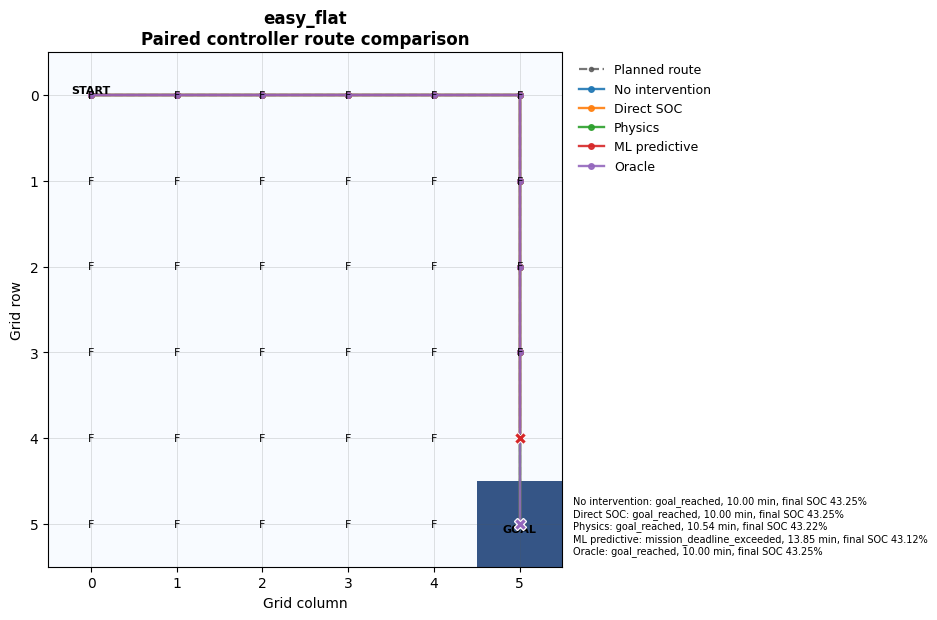

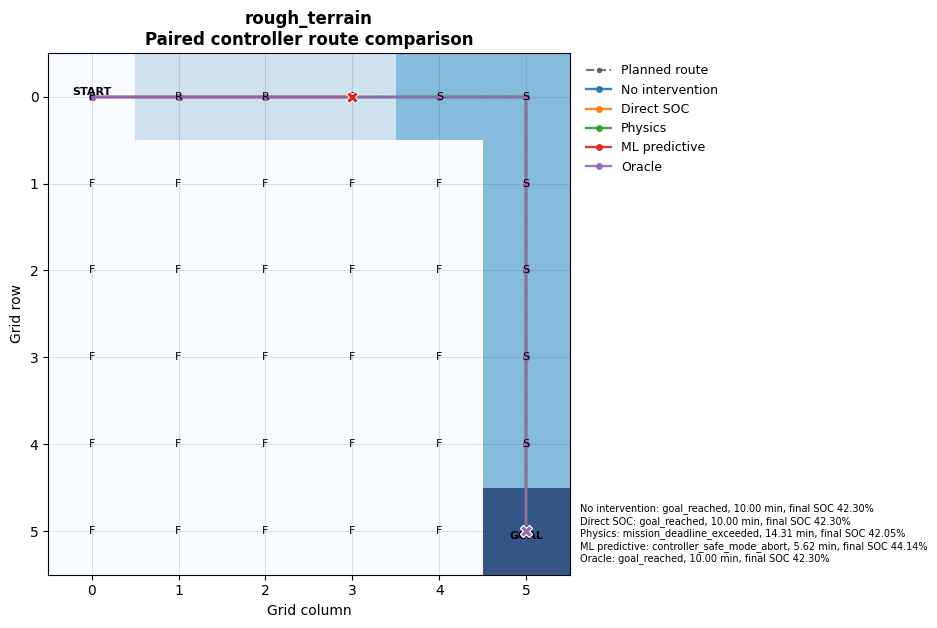

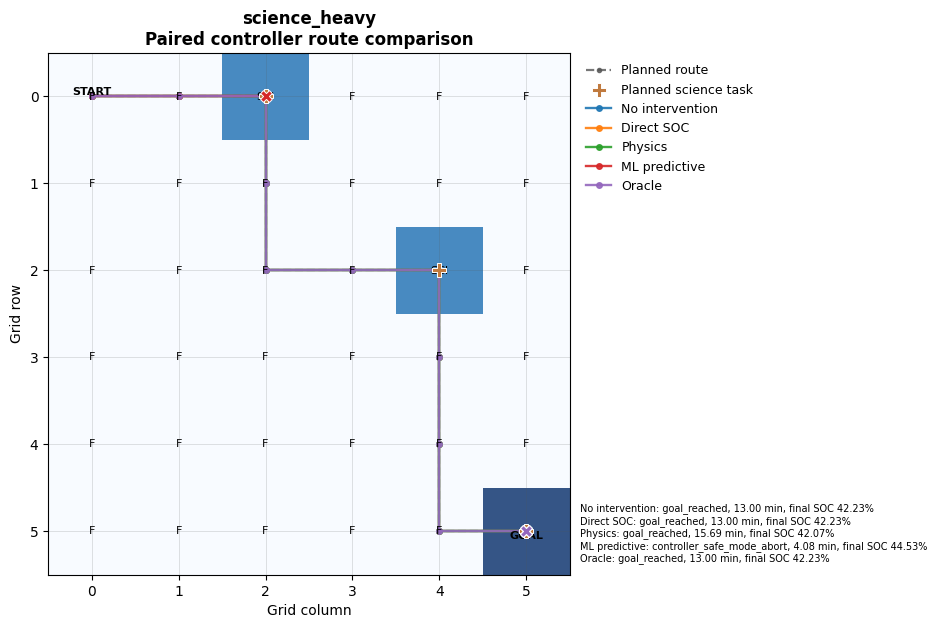

Saved fixed route comparison maps: 6


,mission_id,description,output_path
0,10001,Nominal starting SOC,/content/final_gymnasium_controller_benchmark_...
1,10002,Warning region starting SOC,/content/final_gymnasium_controller_benchmark_...
2,10003,Critical region starting SOC,/content/final_gymnasium_controller_benchmark_...
3,11001,easy_flat,/content/final_gymnasium_controller_benchmark_...
4,11002,rough_terrain,/content/final_gymnasium_controller_benchmark_...
5,11003,science_heavy,/content/final_gymnasium_controller_benchmark_...


In [8]:
# 8. TERRAIN AND ROUTE VISUALISATIONS

TERRAIN_ABBREVIATIONS = {
    0: 'F',
    1: 'R',
    2: 'S',
    3: 'SCI',
    4: 'G',
}

CONTROLLER_DISPLAY_NAMES = {
    'no_intervention': 'No intervention',
    'direct_soc_threshold': 'Direct SOC',
    'constant_current_physics': 'Physics',
    'ml_predictive': 'ML predictive',
    'oracle_future_energy': 'Oracle',
}


def planned_route_coordinates(
    mission_spec,
):
    terrain = np.asarray(
        mission_spec.terrain_grid,
        dtype=int,
    )
    position = np.array([0, 0], dtype=int)
    coordinates = [position.copy()]
    science_coordinates = []

    for action in mission_spec.route_actions:
        action = int(action)
        if action in [0, 1, 2, 3]:
            position = np.clip(
                position
                + np.asarray(
                    movement_delta(action),
                    dtype=int,
                ),
                [0, 0],
                [
                    terrain.shape[0] - 1,
                    terrain.shape[1] - 1,
                ],
            )
        elif action == 4:
            science_coordinates.append(
                position.copy()
            )
        coordinates.append(
            position.copy()
        )

    return (
        np.asarray(
            coordinates,
            dtype=int,
        ),
        (
            np.asarray(
                science_coordinates,
                dtype=int,
            )
            if science_coordinates
            else np.empty(
                (0, 2),
                dtype=int,
            )
        ),
    )


def actual_route_coordinates(
    telemetry_df,
):
    if telemetry_df is None or telemetry_df.empty:
        return np.asarray(
            [[0, 0]],
            dtype=int,
        )

    required = {'step', 'row', 'col'}
    if not required.issubset(
        telemetry_df.columns
    ):
        return np.asarray(
            [[0, 0]],
            dtype=int,
        )

    ordered = telemetry_df.sort_values(
        'step'
    )
    after_positions = (
        ordered[['row', 'col']]
        .to_numpy(dtype=int)
    )
    return np.vstack(
        [
            np.asarray(
                [[0, 0]],
                dtype=int,
            ),
            after_positions,
        ]
    )


def configure_route_axis(
    axis,
    terrain,
):
    axis.imshow(
        terrain,
        interpolation='nearest',
        origin='upper',
        cmap='Blues',
        vmin=0,
        vmax=4,
        alpha=0.82,
    )
    for row_index in range(
        terrain.shape[0]
    ):
        for col_index in range(
            terrain.shape[1]
        ):
            terrain_code = int(
                terrain[
                    row_index,
                    col_index,
                ]
            )
            axis.text(
                col_index,
                row_index,
                TERRAIN_ABBREVIATIONS.get(
                    terrain_code,
                    '?',
                ),
                ha='center',
                va='center',
                fontsize=8,
            )

    axis.set_xticks(
        np.arange(
            terrain.shape[1]
        )
    )
    axis.set_yticks(
        np.arange(
            terrain.shape[0]
        )
    )
    axis.set_xlabel('Grid column')
    axis.set_ylabel('Grid row')
    axis.grid(
        True,
        linewidth=0.6,
        alpha=0.20,
        color='#555555',
    )
    axis.text(
        0,
        0,
        'START',
        ha='center',
        va='bottom',
        fontsize=8,
        fontweight='bold',
    )
    axis.text(
        terrain.shape[1] - 1,
        terrain.shape[0] - 1,
        'GOAL',
        ha='center',
        va='top',
        fontsize=8,
        fontweight='bold',
    )


def plot_controller_route_comparison(
    mission_spec,
    telemetry_df,
    summary_df,
    output_path=None,
    show_plot=True,
):
    terrain = np.asarray(
        mission_spec.terrain_grid,
        dtype=int,
    )
    planned_coordinates, planned_science = (
        planned_route_coordinates(
            mission_spec
        )
    )

    figure, axis = plt.subplots(
        figsize=(8.5, 7.0)
    )
    configure_route_axis(
        axis,
        terrain,
    )

    axis.plot(
        planned_coordinates[:, 1],
        planned_coordinates[:, 0],
        linestyle='--',
        marker='.',
        linewidth=1.6,
        color='#555555',
        alpha=0.8,
        label='Planned route',
    )

    if len(planned_science) > 0:
        axis.scatter(
            planned_science[:, 1],
            planned_science[:, 0],
            marker='P',
            s=90,
            color='#C07A3E',
            edgecolor='white',
            linewidth=0.7,
            label='Planned science task',
            zorder=4,
        )

    status_lines = []

    if (
        telemetry_df is not None
        and not telemetry_df.empty
        and 'controller'
        in telemetry_df.columns
    ):
        for (
            controller_name,
            controller_rows,
        ) in telemetry_df.groupby(
            'controller',
            sort=False,
        ):
            coordinates = (
                actual_route_coordinates(
                    controller_rows
                )
            )
            display_name = CONTROLLER_DISPLAY_NAMES.get(
                controller_name,
                controller_name,
            )
            route_line = axis.plot(
                coordinates[:, 1],
                coordinates[:, 0],
                marker='o',
                markersize=4,
                linewidth=1.7,
                alpha=0.9,
                label=display_name,
            )[0]
            axis.scatter(
                coordinates[-1, 1],
                coordinates[-1, 0],
                marker='X',
                s=72,
                color=route_line.get_color(),
                edgecolor='white',
                linewidth=0.7,
                zorder=5,
            )

            summary_match = summary_df[
                summary_df['controller']
                == controller_name
            ]
            if not summary_match.empty:
                row = summary_match.iloc[0]
                status_lines.append(
                    f'{display_name}: '
                    f'{row["terminated_reason"]}, '
                    f'{row["elapsed_time_min"]:.2f} min, '
                    f'final SOC {row["final_soc"]:.2f}%'
                )

    axis.set_title(
        f'{mission_spec.description}\n'
        'Paired controller route comparison',
        fontsize=12,
        fontweight='semibold',
    )
    axis.legend(
        loc='upper left',
        bbox_to_anchor=(1.01, 1.0),
        frameon=False,
        fontsize=9,
    )

    if status_lines:
        axis.text(
            1.02,
            0.02,
            '\n'.join(status_lines),
            transform=axis.transAxes,
            va='bottom',
            fontsize=7,
        )

    figure.tight_layout()

    if output_path is not None:
        figure.savefig(
            output_path,
            dpi=300,
            bbox_inches='tight',
        )

    if show_plot:
        plt.show()
    plt.close(figure)


fixed_route_manifest = []

for spec in fixed_specs:
    mission_rows = fixed_telemetry_df[
        fixed_telemetry_df['mission_id']
        == spec.mission_id
    ]
    mission_summary = fixed_summary_df[
        fixed_summary_df['mission_id']
        == spec.mission_id
    ]
    output_path = (
        ROUTE_OUTPUT_DIR
        / (
            f'fixed_mission_{spec.mission_id}_'
            'all_controllers_route.png'
        )
    )

    plot_controller_route_comparison(
        mission_spec=spec,
        telemetry_df=mission_rows,
        summary_df=mission_summary,
        output_path=output_path,
        show_plot=False,
    )
    fixed_route_manifest.append(
        {
            'mission_id': int(
                spec.mission_id
            ),
            'description': (
                spec.description
            ),
            'output_path': str(
                output_path
            ),
        }
    )

fixed_route_manifest_df = pd.DataFrame(
    fixed_route_manifest
)
fixed_route_manifest_df.to_csv(
    ROUTE_OUTPUT_DIR
    / 'fixed_route_visualisation_manifest.csv',
    index=False,
)

# Display the three route profile comparisons.
for description in [
    'easy_flat',
    'rough_terrain',
    'science_heavy',
]:
    spec = next(
        item
        for item in fixed_specs
        if item.description == description
    )

    plot_controller_route_comparison(
        mission_spec=spec,
        telemetry_df=fixed_telemetry_df[
            fixed_telemetry_df['mission_id']
            == spec.mission_id
        ],
        summary_df=fixed_summary_df[
            fixed_summary_df['mission_id']
            == spec.mission_id
        ],
        show_plot=True,
    )

print(
    'Saved fixed route comparison maps:',
    len(fixed_route_manifest_df),
)
display(fixed_route_manifest_df)

In [9]:
# 9. PAIRED RANDOMISED CONTROLLER BENCHMARK

random_specs = [
    generate_mission_spec(
        mission_id=20_000 + index,
        seed=RANDOM_SEED + 1_000 + index,
    )
    for index in range(
        N_RANDOM_MISSIONS
    )
]

random_telemetry_parts = []
random_summary_rows = []

for mission_index, spec in enumerate(
    random_specs,
    start=1,
):
    for controller_name in CONTROLLERS:
        telemetry, summary = run_mission(
            spec,
            controller_name,
        )
        random_telemetry_parts.append(
            telemetry
        )
        random_summary_rows.append(
            summary
        )

    if (
        mission_index % 50 == 0
        or mission_index
        == N_RANDOM_MISSIONS
    ):
        print(
            f'Completed paired missions: '
            f'{mission_index}/'
            f'{N_RANDOM_MISSIONS}'
        )

random_telemetry_df = pd.concat(
    random_telemetry_parts,
    ignore_index=True,
)
random_summary_df = pd.DataFrame(
    random_summary_rows
)

random_telemetry_df.to_csv(
    RANDOM_OUTPUT_DIR
    / 'randomised_all_controller_telemetry.csv',
    index=False,
)
random_summary_df.to_csv(
    RANDOM_OUTPUT_DIR
    / 'randomised_all_controller_summary.csv',
    index=False,
)

controller_summary_df = (
    random_summary_df
    .groupby('controller')
    .agg(
        missions=(
            'mission_id',
            'nunique',
        ),
        goal_reached_rate=(
            'goal_reached',
            'mean',
        ),
        safe_mission_success_rate=(
            'safe_mission_success',
            'mean',
        ),
        safety_violation_rate=(
            'safety_violation',
            'mean',
        ),
        deadline_failure_rate=(
            'deadline_exceeded',
            'mean',
        ),
        mean_action_completion=(
            'action_completion_fraction',
            'mean',
        ),
        mean_science_completion=(
            'science_completion_fraction',
            'mean',
        ),
        mean_elapsed_time_min=(
            'elapsed_time_min',
            'mean',
        ),
        mean_final_soc=(
            'final_soc',
            'mean',
        ),
        mean_energy_used_wh=(
            'total_energy_used_wh',
            'mean',
        ),
        mean_peak_power_w=(
            'peak_power_w',
            'mean',
        ),
        mean_unnecessary_interventions=(
            'unnecessary_interventions',
            'mean',
        ),
        mean_missed_critical_steps=(
            'missed_critical_steps',
            'mean',
        ),
    )
    .reset_index()
)

controller_summary_df.to_csv(
    RANDOM_OUTPUT_DIR
    / 'controller_summary.csv',
    index=False,
)

paired_metrics = [
    'goal_reached',
    'safe_mission_success',
    'safety_violation',
    'deadline_exceeded',
    'action_completion_fraction',
    'science_completion_fraction',
    'elapsed_time_min',
    'final_soc',
    'total_energy_used_wh',
    'peak_power_w',
    'unnecessary_interventions',
    'missed_critical_steps',
]
comparison_controllers = [
    controller
    for controller in CONTROLLERS
    if controller != 'ml_predictive'
]

paired_rows = []
for metric in paired_metrics:
    for comparison_controller in (
        comparison_controllers
    ):
        paired_rows.append(
            paired_bootstrap_difference(
                paired_df=random_summary_df,
                metric=metric,
                comparison_controller=(
                    comparison_controller
                ),
            )
        )

paired_comparison_df = pd.DataFrame(
    paired_rows
)
paired_comparison_df.to_csv(
    RANDOM_OUTPUT_DIR
    / 'paired_ml_controller_differences.csv',
    index=False,
)

print('Randomised controller summary:')
display(controller_summary_df)

print(
    'Paired ML minus comparator '
    'bootstrap intervals:'
)
display(paired_comparison_df)

Completed paired missions: 50/200
Completed paired missions: 100/200
Completed paired missions: 150/200
Completed paired missions: 200/200
Randomised controller summary:


,controller,missions,goal_reached_rate,safe_mission_success_rate,safety_violation_rate,deadline_failure_rate,mean_action_completion,mean_science_completion,mean_elapsed_time_min,mean_final_soc,mean_energy_used_wh,mean_peak_power_w,mean_unnecessary_interventions,mean_missed_critical_steps
0,constant_current_physics,200,0.400,0.400,0.000,0.240,0.643240,0.756667,9.761538,43.331046,17.238463,99.633875,1.235,0.00
1,direct_soc_threshold,200,0.500,0.500,0.000,0.255,0.761004,0.863333,11.090385,42.950148,20.355309,118.135909,0.005,0.00
2,ml_predictive,200,0.345,0.345,0.000,0.120,0.540623,0.674167,8.228462,43.674913,14.519561,98.426021,0.850,0.00
3,no_intervention,200,1.000,0.755,0.245,0.000,1.000000,1.000000,12.095000,42.354991,25.464331,160.433464,0.000,2.66
4,oracle_future_energy,200,0.500,0.500,0.000,0.255,0.753455,0.850833,11.010769,42.971501,20.181520,117.416143,0.000,0.00


Paired ML minus comparator bootstrap intervals:


,metric,comparison_controller,n_missions,mean_difference,ci_low,ci_high
0,goal_reached,no_intervention,200,-0.655000,-0.720125,-0.589875
1,goal_reached,direct_soc_threshold,200,-0.155000,-0.205000,-0.105000
2,goal_reached,constant_current_physics,200,-0.055000,-0.090000,-0.030000
3,goal_reached,oracle_future_energy,200,-0.155000,-0.205000,-0.105000
4,safe_mission_success,no_intervention,200,-0.410000,-0.485000,-0.345000
5,safe_mission_success,direct_soc_threshold,200,-0.155000,-0.205000,-0.110000
6,safe_mission_success,constant_current_physics,200,-0.055000,-0.090000,-0.025000
7,safe_mission_success,oracle_future_energy,200,-0.155000,-0.210000,-0.110000
8,safety_violation,no_intervention,200,-0.245000,-0.305000,-0.190000
9,safety_violation,direct_soc_threshold,200,0.000000,0.000000,0.000000


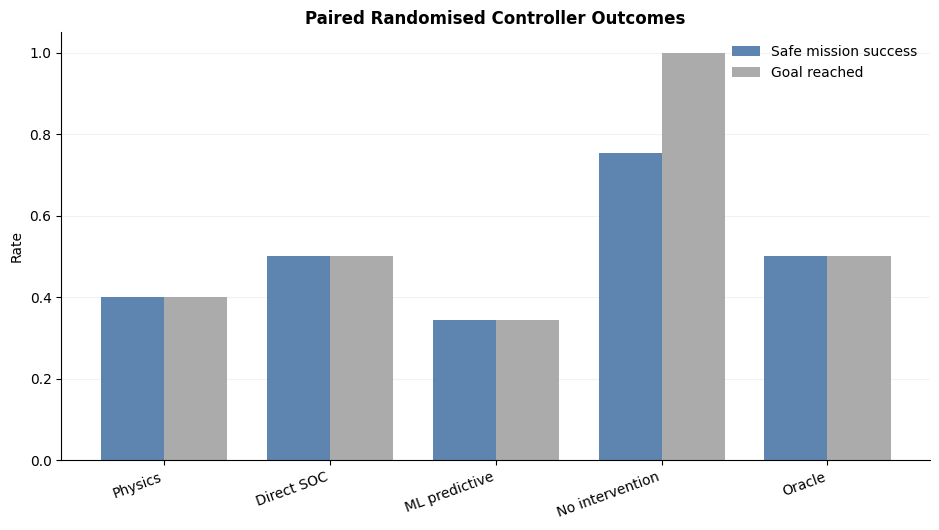

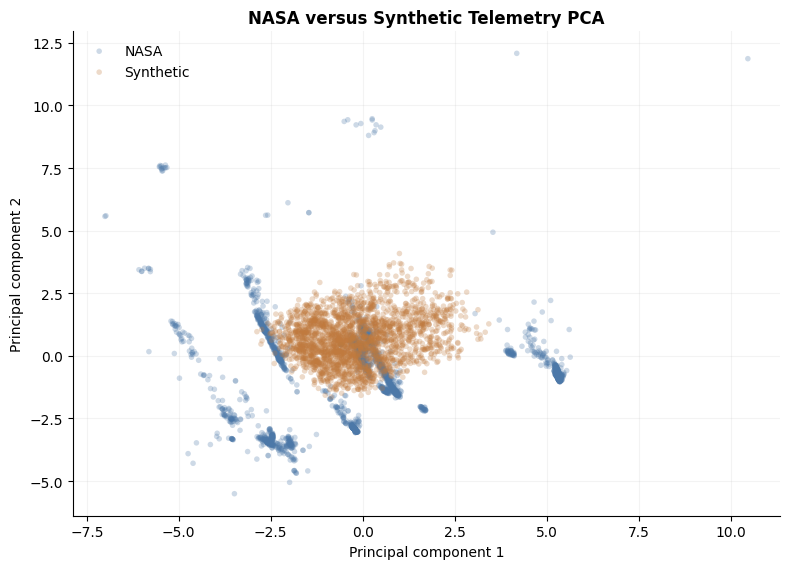

Pre/Post clipping audit:


,feature,preclip_below_q01_fraction,preclip_above_q99_fraction,postclip_below_q01_fraction,postclip_above_q99_fraction
0,voltage_measured_v,0.000000,0.0,0.0,0.0
1,current_measured_a,0.000000,0.0,0.0,0.0
2,temperature_measured_c,0.002067,0.0,0.0,0.0
3,current_load_a,0.000000,0.0,0.0,0.0
4,voltage_load_v,0.000000,0.0,0.0,0.0
5,operational_soc_percent,0.000000,0.0,0.0,0.0
6,prior_capacity_estimate_ah,0.000000,0.0,0.0,0.0


Multivariate domain audit:


,features_used,roc_auc_mean,roc_auc_std,n_nasa_rows,n_synthetic_rows
0,"voltage_measured_v,current_measured_a,temperat...",1.0,0.0,2419,2419


Failure case catalogue:


,mission_id,category
0,20017,ML loses to physics baseline
1,20017,ML unnecessary intervention
2,20027,ML unnecessary intervention
3,20033,ML unnecessary intervention
4,20035,ML loses to physics baseline
5,20035,ML unnecessary intervention
6,20038,ML unnecessary intervention
7,20046,ML unnecessary intervention
8,20050,ML unnecessary intervention
9,20054,ML unnecessary intervention


Saved failure case route maps: 3


In [10]:
# 10. CONTROLLER PLOTS, DOMAIN SHIFT AUDIT, AND FAILURE CASE ROUTES

# Controller outcome plot.
plot_df = controller_summary_df.set_index(
    'controller'
)
x_positions = np.arange(
    len(plot_df)
)
bar_width = 0.38

figure, axis = plt.subplots(
    figsize=(9.5, 5.4)
)
axis.bar(
    x_positions
    - bar_width / 2,
    plot_df[
        'safe_mission_success_rate'
    ],
    width=bar_width,
    color='#4C78A8',
    alpha=0.90,
    label='Safe mission success',
)
axis.bar(
    x_positions
    + bar_width / 2,
    plot_df[
        'goal_reached_rate'
    ],
    width=bar_width,
    color='#A0A0A0',
    alpha=0.88,
    label='Goal reached',
)
axis.set_xticks(x_positions)
axis.set_xticklabels(
    [
        CONTROLLER_DISPLAY_NAMES.get(
            name,
            name,
        )
        for name in plot_df.index
    ],
    rotation=20,
    ha='right',
)
axis.set_ylabel('Rate')
axis.set_ylim(0.0, 1.05)
axis.set_title(
    'Paired Randomised Controller Outcomes',
    fontsize=12,
    fontweight='semibold',
)
axis.grid(axis='y', alpha=0.16, linewidth=0.8)
axis.set_axisbelow(True)
axis.spines['top'].set_visible(False)
axis.spines['right'].set_visible(False)
axis.legend(frameon=False)
figure.tight_layout()
figure.savefig(
    PLOT_OUTPUT_DIR
    / 'paired_controller_outcomes.png',
    dpi=300,
    bbox_inches='tight',
)
plt.show()
plt.close(figure)

# Domain shift audit uses no intervention telemetry only to avoid duplicating the same mission across controllers.
synthetic_audit_df = random_telemetry_df[
    random_telemetry_df['controller']
    == 'no_intervention'
].copy()

audit_features = [
    feature
    for feature in all_required_features
    if (
        feature in nasa_reference_df.columns
        and feature in synthetic_audit_df.columns
    )
]

clip_rows = []
for feature in audit_features:
    preclip_column = (
        f'preclip_{feature}'
    )
    if preclip_column not in (
        synthetic_audit_df.columns
    ):
        continue

    low = feature_quantile(
        feature,
        'q01',
        -np.inf,
    )
    high = feature_quantile(
        feature,
        'q99',
        np.inf,
    )
    preclip_values = (
        synthetic_audit_df[
            preclip_column
        ].astype(float)
    )
    postclip_values = (
        synthetic_audit_df[
            feature
        ].astype(float)
    )

    clip_rows.append(
        {
            'feature': feature,
            'preclip_below_q01_fraction': float(
                (preclip_values < low).mean()
            ),
            'preclip_above_q99_fraction': float(
                (preclip_values > high).mean()
            ),
            'postclip_below_q01_fraction': float(
                (postclip_values < low).mean()
            ),
            'postclip_above_q99_fraction': float(
                (postclip_values > high).mean()
            ),
        }
    )

clipping_audit_df = pd.DataFrame(
    clip_rows
)
clipping_audit_df.to_csv(
    AUDIT_OUTPUT_DIR
    / 'pre_post_clipping_audit.csv',
    index=False,
)

domain_audit_summary = pd.DataFrame(
    [
        {
            'features_used': ','.join(
                audit_features
            ),
            'roc_auc_mean': np.nan,
            'roc_auc_std': np.nan,
            'n_nasa_rows': 0,
            'n_synthetic_rows': 0,
        }
    ]
)

if len(audit_features) >= 2:
    nasa_domain = (
        nasa_reference_df[
            audit_features
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .dropna()
    )
    synthetic_domain = (
        synthetic_audit_df[
            audit_features
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .dropna()
    )

    n_domain_rows = int(
        min(
            len(nasa_domain),
            len(synthetic_domain),
            5_000,
        )
    )

    if n_domain_rows >= 50:
        nasa_domain = nasa_domain.sample(
            n=n_domain_rows,
            random_state=RANDOM_SEED,
        )
        synthetic_domain = (
            synthetic_domain.sample(
                n=n_domain_rows,
                random_state=RANDOM_SEED,
            )
        )

        domain_X = pd.concat(
            [
                nasa_domain,
                synthetic_domain,
            ],
            ignore_index=True,
        )
        domain_y = np.concatenate(
            [
                np.zeros(
                    n_domain_rows,
                    dtype=int,
                ),
                np.ones(
                    n_domain_rows,
                    dtype=int,
                ),
            ]
        )

        domain_pipeline = Pipeline(
            [
                (
                    'scaler',
                    StandardScaler(),
                ),
                (
                    'classifier',
                    LogisticRegression(
                        max_iter=1_000,
                        random_state=(
                            RANDOM_SEED
                        ),
                    ),
                ),
            ]
        )
        domain_cv = StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=RANDOM_SEED,
        )
        domain_auc = cross_val_score(
            domain_pipeline,
            domain_X,
            domain_y,
            cv=domain_cv,
            scoring='roc_auc',
        )

        domain_audit_summary = pd.DataFrame(
            [
                {
                    'features_used': ','.join(
                        audit_features
                    ),
                    'roc_auc_mean': float(
                        domain_auc.mean()
                    ),
                    'roc_auc_std': float(
                        domain_auc.std(ddof=1)
                    ),
                    'n_nasa_rows': int(
                        n_domain_rows
                    ),
                    'n_synthetic_rows': int(
                        n_domain_rows
                    ),
                }
            ]
        )

        scaled_domain = (
            StandardScaler()
            .fit_transform(domain_X)
        )
        pca = PCA(
            n_components=2,
            random_state=RANDOM_SEED,
        )
        pca_values = pca.fit_transform(
            scaled_domain
        )
        pca_df = pd.DataFrame(
            {
                'pc1': pca_values[:, 0],
                'pc2': pca_values[:, 1],
                'domain': np.where(
                    domain_y == 0,
                    'NASA',
                    'Synthetic',
                ),
            }
        )

        figure, axis = plt.subplots(
            figsize=(8.0, 5.8)
        )
        domain_colours = {
            'NASA': '#4C78A8',
            'Synthetic': '#C07A3E',
        }
        for domain_name, rows in (
            pca_df.groupby('domain')
        ):
            axis.scatter(
                rows['pc1'],
                rows['pc2'],
                alpha=0.28,
                s=16,
                color=domain_colours.get(
                    domain_name,
                    '#777777',
                ),
                edgecolors='none',
                label=domain_name,
            )
        axis.set_xlabel('Principal component 1')
        axis.set_ylabel('Principal component 2')
        axis.set_title(
            'NASA versus Synthetic Telemetry PCA',
            fontsize=12,
            fontweight='semibold',
        )
        axis.grid(alpha=0.14, linewidth=0.8)
        axis.set_axisbelow(True)
        axis.spines['top'].set_visible(False)
        axis.spines['right'].set_visible(False)
        axis.legend(frameon=False)
        figure.tight_layout()
        figure.savefig(
            AUDIT_OUTPUT_DIR
            / 'nasa_vs_synthetic_pca.png',
            dpi=300,
            bbox_inches='tight',
        )
        plt.show()
        plt.close(figure)

domain_audit_summary.to_csv(
    AUDIT_OUTPUT_DIR
    / 'multivariate_domain_audit.csv',
    index=False,
)

print('Pre/Post clipping audit:')
display(clipping_audit_df)
print('Multivariate domain audit:')
display(domain_audit_summary)

# Failure case catalogue from paired mission summaries.
summary_pivot = (
    random_summary_df
    .set_index(
        [
            'mission_id',
            'controller',
        ]
    )
)

failure_rows = []

for spec in random_specs:
    mission_id = int(spec.mission_id)

    try:
        ml = summary_pivot.loc[
            (
                mission_id,
                'ml_predictive',
            )
        ]
        direct = summary_pivot.loc[
            (
                mission_id,
                'direct_soc_threshold',
            )
        ]
        physics = summary_pivot.loc[
            (
                mission_id,
                'constant_current_physics',
            )
        ]
    except KeyError:
        continue

    if (
        bool(ml['safe_mission_success'])
        and not bool(
            direct['safe_mission_success']
        )
    ):
        failure_rows.append(
            {
                'mission_id': mission_id,
                'category': (
                    'ML improves over direct threshold'
                ),
            }
        )

    if (
        bool(physics['safe_mission_success'])
        and not bool(
            ml['safe_mission_success']
        )
    ):
        failure_rows.append(
            {
                'mission_id': mission_id,
                'category': (
                    'ML loses to physics baseline'
                ),
            }
        )

    if int(
        ml['unnecessary_interventions']
    ) > 0:
        failure_rows.append(
            {
                'mission_id': mission_id,
                'category': (
                    'ML unnecessary intervention'
                ),
            }
        )

    if int(
        ml['missed_critical_steps']
    ) > 0:
        failure_rows.append(
            {
                'mission_id': mission_id,
                'category': (
                    'ML missed critical state'
                ),
            }
        )

failure_case_catalog_df = (
    pd.DataFrame(
        failure_rows
    )
    .drop_duplicates()
    if failure_rows
    else pd.DataFrame(
        columns=[
            'mission_id',
            'category',
        ]
    )
)
failure_case_catalog_df.to_csv(
    FAILURE_OUTPUT_DIR
    / 'failure_case_catalogue.csv',
    index=False,
)

# Save at most three paired failure case route maps.
failure_route_rows = []
if not failure_case_catalog_df.empty:
    selected_failure_ids = (
        failure_case_catalog_df[
            'mission_id'
        ]
        .drop_duplicates()
        .head(3)
        .tolist()
    )

    spec_lookup = {
        int(spec.mission_id): spec
        for spec in random_specs
    }

    for mission_id in selected_failure_ids:
        spec = spec_lookup[int(mission_id)]
        output_path = (
            FAILURE_OUTPUT_DIR
            / (
                f'failure_mission_{mission_id}_'
                'controller_routes.png'
            )
        )
        plot_controller_route_comparison(
            mission_spec=spec,
            telemetry_df=(
                random_telemetry_df[
                    random_telemetry_df[
                        'mission_id'
                    ]
                    == mission_id
                ]
            ),
            summary_df=(
                random_summary_df[
                    random_summary_df[
                        'mission_id'
                    ]
                    == mission_id
                ]
            ),
            output_path=output_path,
            show_plot=False,
        )
        failure_route_rows.append(
            {
                'mission_id': int(
                    mission_id
                ),
                'output_path': str(
                    output_path
                ),
            }
        )

failure_route_manifest_df = pd.DataFrame(
    failure_route_rows,
    columns=[
        'mission_id',
        'output_path',
    ],
)
failure_route_manifest_df.to_csv(
    FAILURE_OUTPUT_DIR
    / 'failure_route_manifest.csv',
    index=False,
)

print('Failure case catalogue:')
display(failure_case_catalog_df)
print(
    'Saved failure case route maps:',
    len(failure_route_manifest_df),
)

In [11]:
# 11. SAVE CONFIGURATION, COPY OUTPUTS, AND FINAL SUMMARY

run_configuration = {
    'random_seed': RANDOM_SEED,
    'n_random_missions': (
        N_RANDOM_MISSIONS
    ),
    'controllers': list(
        CONTROLLERS
    ),
    'forecast_horizon_seconds': (
        HORIZON_SECONDS
    ),
    'base_action_duration_minutes': (
        BASE_ACTION_DURATION_MIN
    ),
    'warning_power_multiplier': (
        WARNING_POWER_MULTIPLIER
    ),
    'safe_mode_power_multiplier': (
        SAFE_MODE_POWER_MULTIPLIER
    ),
    'model_directory': str(
        MODEL_DIR
    ),
    'regression_features': (
        soc_drop_features
    ),
    'classification_features': (
        future_risk_features
    ),
    'reduced_load_tradeoff': (
        'Task power is reduced, but action duration '
        'increases by 1 / power multiplier and can '
        'cause deadline failure.'
    ),
    'domain_transfer_note': (
        'Equivalent cell telemetry is a heuristic '
        'software-in-the-loop interface. The domain '
        'audit measures discrepancy but does not '
        'validate transfer to a physical rover.'
    ),
    'gymnasium_role': (
        'Route based paired controller benchmark; '
        'no reinforcement learning policy or '
        'autonomous route planning.'
    ),
}

with open(
    BASE_OUTPUT_DIR
    / 'gymnasium_run_configuration.json',
    'w',
    encoding='utf-8',
) as file:
    json.dump(
        run_configuration,
        file,
        indent=2,
    )

final_summary = {
    'fixed_missions': int(
        fixed_summary_df[
            'mission_id'
        ].nunique()
    ),
    'fixed_controller_runs': int(
        len(fixed_summary_df)
    ),
    'random_missions': int(
        random_summary_df[
            'mission_id'
        ].nunique()
    ),
    'random_controller_runs': int(
        len(random_summary_df)
    ),
    'controllers': list(
        CONTROLLERS
    ),
    'domain_classifier_auc_mean': (
        float(
            domain_audit_summary[
                'roc_auc_mean'
            ].iloc[0]
        )
        if not domain_audit_summary.empty
        else np.nan
    ),
    'fixed_route_visualisations': int(
        len(fixed_route_manifest_df)
    ),
    'failure_case_route_visualisations': int(
        len(failure_route_manifest_df)
    ),
}

with open(
    BASE_OUTPUT_DIR
    / 'final_gymnasium_summary.json',
    'w',
    encoding='utf-8',
) as file:
    json.dump(
        final_summary,
        file,
        indent=2,
        allow_nan=True,
    )

try:
    DRIVE_OUTPUT_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )
    for source in BASE_OUTPUT_DIR.rglob('*'):
        if source.is_file():
            destination = (
                DRIVE_OUTPUT_DIR
                / source.relative_to(
                    BASE_OUTPUT_DIR
                )
            )
            destination.parent.mkdir(
                parents=True,
                exist_ok=True,
            )
            shutil.copy2(
                source,
                destination,
            )

    print(
        'Copied outputs to Drive:',
        DRIVE_OUTPUT_DIR,
    )
except Exception as exc:
    print(
        'Could not copy outputs to Drive:',
        exc,
    )

Copied outputs to Drive: /content/drive/MyDrive/dissertation/03_gymnasium_controller_benchmark_outputs
